In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
x,y_true=make_blobs(n_samples=500,centers=3,cluster_std=0.60,random_state=42)

In [4]:
df=pd.DataFrame(x,columns=['Feature_1','Feature_2'])

In [5]:
df

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [6]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(df)

In [7]:
inertia=[]
K_range=range(1,11)



In [8]:
for k in K_range:
    Kmeans=KMeans(n_clusters=k,random_state=42)
    Kmeans.fit(x_scaled)
    inertia.append(Kmeans.inertia_)

In [9]:
inertia

[1000.0,
 297.8954141051723,
 11.57548472310498,
 9.752067977356841,
 8.257175272446284,
 6.9175773204168,
 6.334755391595291,
 5.704177177901429,
 5.060234133532076,
 4.762361898130396]

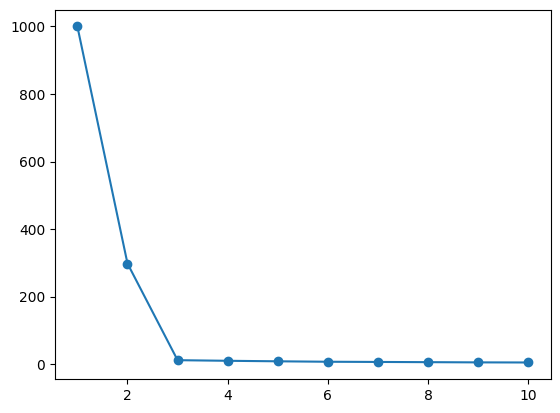

In [10]:
plt.plot(K_range,inertia,marker='o')

In [11]:
Kmeans_final=KMeans(n_clusters=3,random_state=42)

In [12]:
cluster_labels=Kmeans_final.fit_predict(x_scaled)

In [13]:
df['cluster']=cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

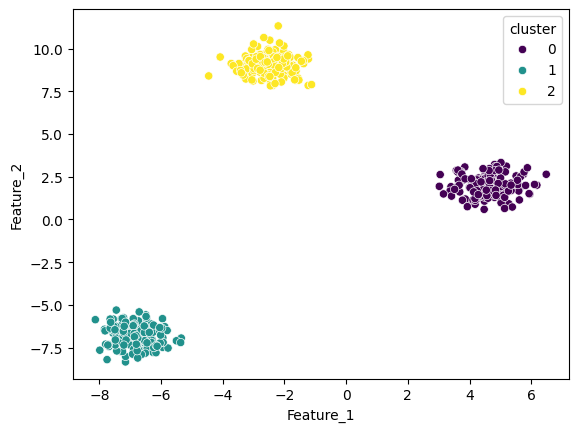

In [15]:
sns.scatterplot(x=df['Feature_1'],
                y=df['Feature_2'],
                hue=df['cluster'],
                palette='viridis')